# QUI SONT LES EMPRUNTEURS

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns

from kiblib.utils.db import DbConn

import warnings
warnings.filterwarnings("ignore")

In [2]:
db_conn = DbConn().create_engine()

In [3]:
# PARAMETRAGE DES GRAPHIQUES MATPLOLIB

params = {'axes.titlesize': 15,
          'axes.titleweight':'bold',
          'axes.grid':'y',
          'axes.labelweight':'bold',
          'axes.labelsize':15,
          'legend.shadow':True,
          'figure.subplot.hspace': 0.4,
          'figure.figsize':(15,5)
         }

plt.rcParams.update(params)

In [4]:
# DÉFINITION D'UNE FONCTION POUR AFFICHER LES % DES PIEPLOT + VALEURS BRUTES

def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

In [5]:
query = """SELECT MAX(date_extraction) AS date_max
FROM statdb.stat_adherents sa"""

df_date_max = pd.read_sql(query,db_conn)

# On met dans une variable la valeurs date qui nous intéresse :

date_max = df_date_max.iloc[0]["date_max"]
date_max = date_max.isoformat()
#date_max

timestamp = date.today().strftime("%d-%m-%Y")
#timestamp

query = f"SELECT * FROM statdb.stat_adherents sa WHERE date_extraction = '{date_max}'"

inscrits = pd.read_sql(query,db_conn,parse_dates="date_max")
#inscrits

inscrits['nb_venues_prets'] = inscrits['nb_venues_prets_bus'] + inscrits['nb_venues_prets_mediatheque']

emprunteurs = inscrits[inscrits['nb_venues_prets']>0]

emprunteurs["nombre_emprunteurs"] = 1

emprunteurs_med = emprunteurs[emprunteurs['nb_venues_prets_mediatheque']>0]

total_emprunteurs = len(emprunteurs)

total_emprunteurs_med = len(emprunteurs_med)

### Nombre d'emprunteurs 

In [6]:
print(f"Sur les 12 derniers mois, {total_emprunteurs_med} personnes sont venues emprunter au moins une fois à la médiathèque")

Sur les 12 derniers mois, 9711 personnes sont venues emprunter au moins une fois à la médiathèque


In [7]:
# ON CREE UN DATAFRAME EN NE RETENANT QUE LA COLONNE ÂGE QUI NOUS INTERESSE

emprunteurs_par_age = pd.DataFrame(emprunteurs,columns=["age"])

In [8]:
emprunteurs_par_age["0-2 ans"] = np.where(emprunteurs_par_age["age"].between(0,2),1,0)
emprunteurs_par_age["3-5 ans"] = np.where(emprunteurs_par_age["age"].between(3,5),1,0)
emprunteurs_par_age["6-10 ans"] = np.where(emprunteurs_par_age["age"].between(6,10),1,0)
emprunteurs_par_age["11-14 ans"] = np.where(emprunteurs_par_age["age"].between(11,14),1,0)
emprunteurs_par_age["15-17 ans"] = np.where(emprunteurs_par_age["age"].between(15,17),1,0)
emprunteurs_par_age["18-19 ans"] = np.where(emprunteurs_par_age["age"].between(18,19),1,0)
emprunteurs_par_age["20-24 ans"] = np.where(emprunteurs_par_age["age"].between(20,24),1,0)
emprunteurs_par_age["25-29 ans"] = np.where(emprunteurs_par_age["age"].between(25,29),1,0)
emprunteurs_par_age["30-39 ans"] = np.where(emprunteurs_par_age["age"].between(30,39),1,0)
emprunteurs_par_age["40-54 ans"] = np.where(emprunteurs_par_age["age"].between(40,54),1,0)
emprunteurs_par_age["55-54 ans"] = np.where(emprunteurs_par_age["age"].between(55,64),1,0)
emprunteurs_par_age["65-79 ans"] = np.where(emprunteurs_par_age["age"].between(65,79),1,0)
emprunteurs_par_age["80 ans et plus"] = np.where(emprunteurs_par_age["age"]>=80,1,0)

In [9]:
# Dans un premier temps on supprime la colonne âge...

emprunteurs_par_age = emprunteurs_par_age.drop(labels=["age"],axis=1)

In [10]:
# On fait ensuite la somme de chaque colonne

emprunteurs_par_age = emprunteurs_par_age.sum()

In [11]:
# On transforme le tableau en Dataframe

emprunteurs_par_age = emprunteurs_par_age.reset_index().rename(columns={"index":"tranche d'âge",0:"nombre_emprunteurs"})

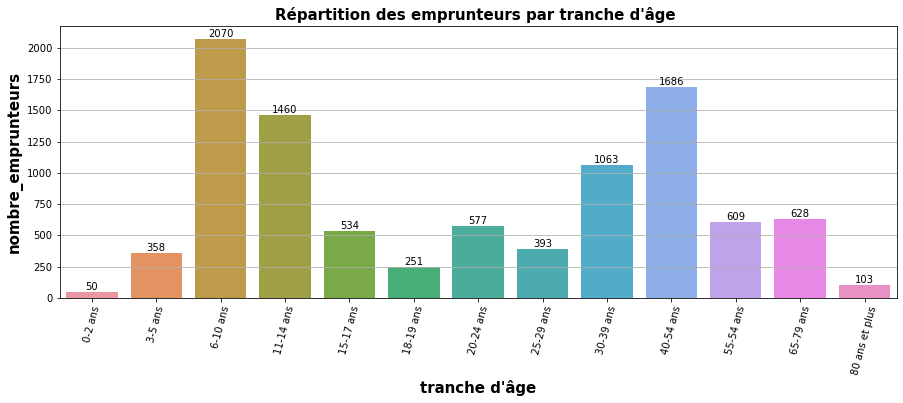

In [12]:
ax = sns.barplot(data=emprunteurs_par_age,x="tranche d'âge",y="nombre_emprunteurs")
ax.set_title("Répartition des emprunteurs par tranche d'âge ")
ax.tick_params(axis="x",rotation=75)

for i in ax.containers:
    ax.bar_label(i,)

In [13]:
total_inscrits = emprunteurs_par_age['nombre_emprunteurs'].sum()

In [14]:
emprunteurs_par_age['nombre_emprunteurs'] = round((emprunteurs_par_age['nombre_emprunteurs'] / total_inscrits)*100,1)

In [15]:
emprunteurs_par_ville = pd.DataFrame(inscrits,columns=["geo_ville"])

In [16]:
# Création d'une colonne pour chaque ville nommée et qui compte le nombre 1 si condition est remplie, sinon O

emprunteurs_par_ville["Roubaix"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("ROUBAIX"),1,0)
emprunteurs_par_ville["Croix"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("CROIX"),1,0)
emprunteurs_par_ville["Hem"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("HEM"),1,0)
emprunteurs_par_ville["Tourcoing"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("TOURCOING"),1,0)
emprunteurs_par_ville["Wattrelos"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("WATTRELOS"),1,0)
emprunteurs_par_ville["Lys-lez-Lannoy"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("LYS-LEZ-LANNOY"),1,0)
emprunteurs_par_ville["Leers"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("LEERS"),1,0)

# Création d'une colonne autre : "Si colonne geo_ville contient au moins une des villes nommées, compter 0, sinon compter 1"

emprunteurs_par_ville["Autre"] = np.where(emprunteurs_par_ville["geo_ville"].str.contains("ROUBAIX|CROIX|HEM|TOURCOING|WATTRELOS|LYS-LEZ-LANNOY|LEERS",regex=True),0,1)


emprunteurs_par_ville["Hors-Roubaix"] = np.where(~emprunteurs_par_ville["geo_ville"].str.contains("ROUBAIX",regex=True),1,0)

In [17]:
emprunteurs_par_ville = emprunteurs_par_ville.drop(labels=["geo_ville"],axis=1)

In [18]:
#emprunteurs_par_ville

In [19]:
repartition_emprunteurs_rbx = emprunteurs_par_ville[['Roubaix','Hors-Roubaix']]
#repartition_emprunteurs_rbx

In [20]:
repartition_emprunteurs_rbx = repartition_emprunteurs_rbx.sum()
#repartition_emprunteurs_rbx

In [21]:
repartition_emprunteurs_rbx = pd.DataFrame(repartition_emprunteurs_rbx)
repartition_emprunteurs_rbx = repartition_emprunteurs_rbx.rename(columns={0:'nombre_emprunteurs'})

In [22]:
emprunteurs_par_ville = emprunteurs_par_ville[['Roubaix',
                                         'Croix',
                                         'Hem',
                                         'Tourcoing',
                                         'Wattrelos',
                                         'Lys-lez-Lannoy',
                                         'Leers',
                                         'Autre'
                                        ]]

In [23]:
# On fait la somme des colonnes créées pour obtenir en ligne un total par ville

emprunteurs_par_ville = emprunteurs_par_ville.sum()

In [24]:
emprunteurs_par_ville = emprunteurs_par_ville.reset_index().rename(columns={"index":"ville d'origine",0:"nombre_emprunteurs"})

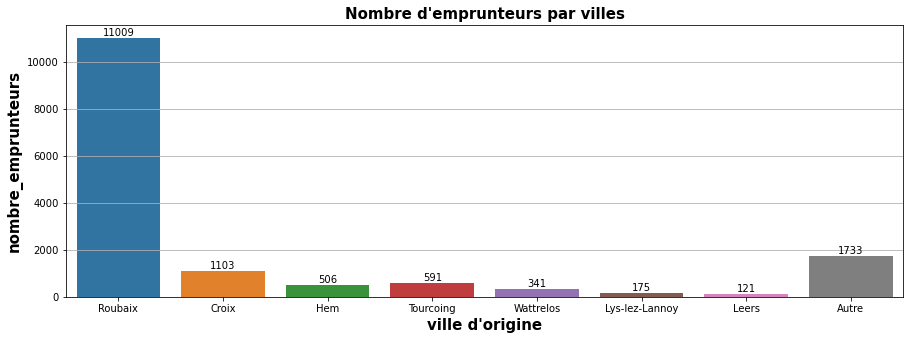

In [25]:
ax = sns.barplot(data=emprunteurs_par_ville,x="ville d'origine",y="nombre_emprunteurs")
ax.set_title("Nombre d'emprunteurs par villes")

for i in ax.containers:
    ax.bar_label(i,)

In [26]:
emprunteurs_par_ville["pourcentage_inscrits"] = (emprunteurs_par_ville["nombre_emprunteurs"] / emprunteurs_par_ville["nombre_emprunteurs"].sum())*100
emprunteurs_par_ville["pourcentage_inscrits"] = emprunteurs_par_ville["pourcentage_inscrits"].round(1)
#emprunteurs_par_ville

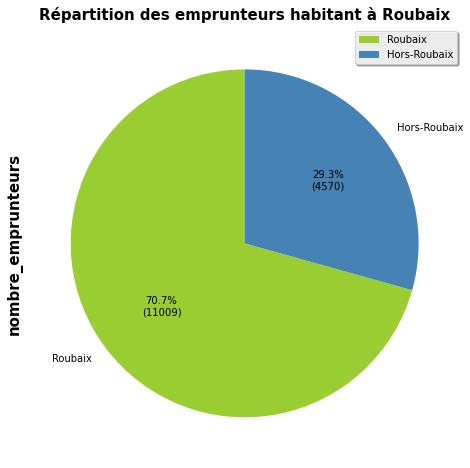

In [27]:
ax = repartition_emprunteurs_rbx.plot.pie(y='nombre_emprunteurs',
                                       figsize=(15,8),
                                       autopct=autopct_format(repartition_emprunteurs_rbx["nombre_emprunteurs"]),
                                       colors=["yellowgreen","steelblue"],
                                       startangle=90,
                                       center=(0,5)
                                      )

ax.set_title("Répartition des emprunteurs habitant à Roubaix")
ax = plt.legend()

In [28]:
# Les catégories sont déjà créées, on fait donc juste un groupby().sum()

emprunteurs_par_sex = emprunteurs.groupby("sexe")["nombre_emprunteurs"].sum()

In [29]:
# On transforme le tableau en Dataframe

emprunteurs_par_sex = pd.DataFrame(emprunteurs_par_sex)

In [30]:
# On change le nom de chaque ligne de l'index sur la base d'une liste

emprunteurs_par_sex = emprunteurs_par_sex.rename(index={'':'Non communiqué','F':'Femme','M':'Homme','N':'Non-pertinent'})

In [31]:
# Suppression des lignes qu'on ne veut pas garder

emprunteurs_par_sex = emprunteurs_par_sex.drop(labels=["Non communiqué","Non-pertinent"],axis=0)

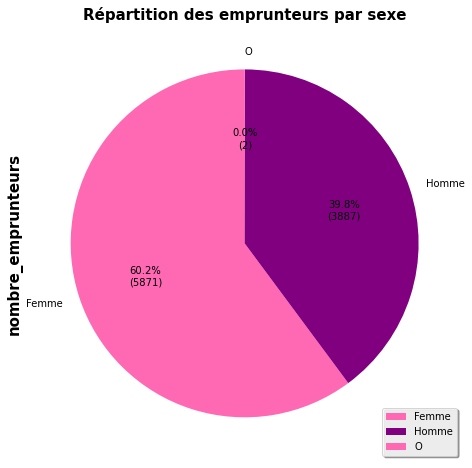

In [32]:
ax = emprunteurs_par_sex.plot.pie(y='nombre_emprunteurs',
                               autopct=autopct_format(emprunteurs_par_sex["nombre_emprunteurs"]),
                               figsize=(15,8),
                               colors=["hotpink","purple"],
                               startangle=90
                              )
ax.set_title("Répartition des emprunteurs par sexe")
ax = plt.legend()

In [33]:
emprunteurs_par_site = emprunteurs.groupby("inscription_code_site")["nombre_emprunteurs"].sum()

In [34]:
emprunteurs_par_site = pd.DataFrame(emprunteurs_par_site)

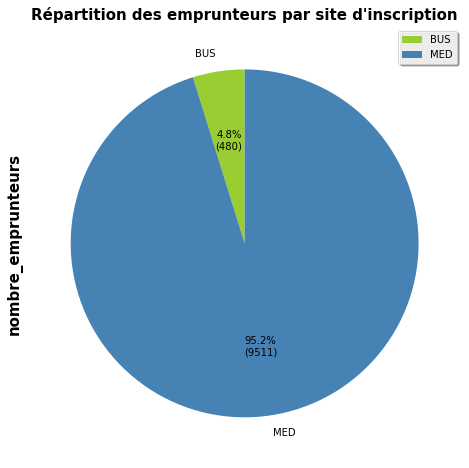

In [35]:
ax = emprunteurs_par_site.plot.pie(y='nombre_emprunteurs',
                               autopct=autopct_format(emprunteurs_par_site["nombre_emprunteurs"]),
                               figsize=(15,8),
                               colors=["yellowgreen","steelblue"],
                                startangle=90
                               )
ax.set_title("Répartition des emprunteurs par site d'inscription")
ax = plt.legend()

In [36]:
emprunteurs_fidelite = pd.DataFrame(inscrits,columns=["inscription_fidelite"])

In [37]:
emprunteurs_fidelite["Moins d'1 an"] = np.where(emprunteurs_fidelite["inscription_fidelite"]==0,1,0)
emprunteurs_fidelite["1 an"] = np.where(emprunteurs_fidelite["inscription_fidelite"]==1,1,0)
emprunteurs_fidelite["2 ans"] = np.where(emprunteurs_fidelite["inscription_fidelite"]==2,1,0)
emprunteurs_fidelite["3 ans"] = np.where(emprunteurs_fidelite["inscription_fidelite"]==3,1,0)
emprunteurs_fidelite["4 ans"] = np.where(emprunteurs_fidelite["inscription_fidelite"]==4,1,0)
emprunteurs_fidelite["Entre 5 et 10 ans"] = np.where(emprunteurs_fidelite["inscription_fidelite"].between(5,10),1,0)
emprunteurs_fidelite["Plus de 10 ans"] = np.where(emprunteurs_fidelite["inscription_fidelite"]>10,1,0)

In [38]:
emprunteurs_fidelite = emprunteurs_fidelite.drop(labels=["inscription_fidelite"],axis=1)

In [39]:
emprunteurs_fidelite = emprunteurs_fidelite.sum()

In [40]:
df_emprunteurs_fidelite = pd.DataFrame(data=emprunteurs_fidelite,columns=["nombre_emprunteurs"])
df_emprunteurs_fidelite = df_emprunteurs_fidelite.reset_index()

In [41]:
df_emprunteurs_fidelite.rename({"index":"annee_fidelite"},axis=1,inplace=True)

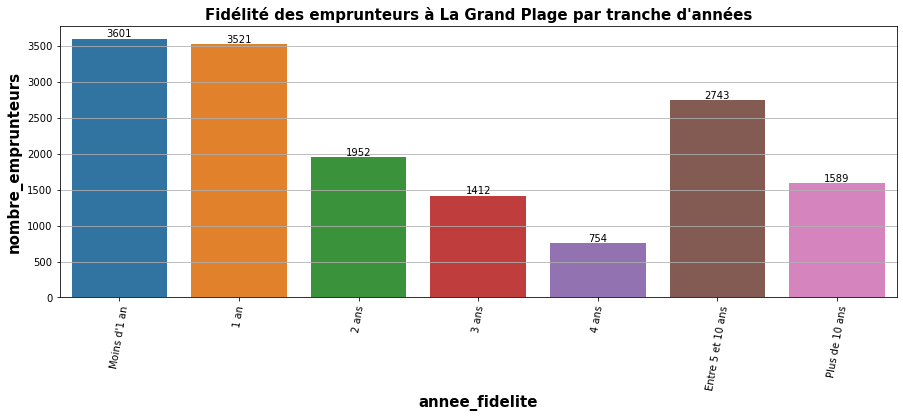

In [42]:
ax = sns.barplot(data=df_emprunteurs_fidelite,
                 x="annee_fidelite",
                 y="nombre_emprunteurs")

ax.set_title("Fidélité des emprunteurs à La Grand Plage par tranche d'années")
ax.tick_params(axis='x',rotation=80)

for i in ax.containers:
    ax.bar_label(i,)

In [43]:
# Création d'un df avec 2 colonnes 'type de carte' et 'nombre d'inscrit

emprunteurs_par_carte = emprunteurs.groupby("inscription_code_carte")["nombre_emprunteurs"].sum().reset_index()

In [44]:
# On remplace l'index numérique par 'inscription_code_carte'

emprunteurs_par_carte = pd.pivot_table(emprunteurs_par_carte,
               index="inscription_code_carte",
              values="nombre_emprunteurs")

In [45]:
#df_emprunteurs_fidelite

In [46]:
# Comme il n'y a pas beaucoup de lignes à renommer on utilise un dictionnaire avec le paramètre rename.(index=)

emprunteurs_par_carte.rename(index={"BIBL":"Médiathèque",
                                 "MEDA":"Médiathèque Plus",
                                 "MEDB": "Médiathèque Plus",
                                 "MEDC":"Médiathèque Plus",
                                 "CLAS":"Autre",
                                 "COLI":"Autre",
                                 "COLS":"Autre",
                                 "CSVT":"Autre",
                                 "ECOL": "Autre",
                                 "MEDP":"Autre",
                                 "CSLT":"Consultation\nsur place"},inplace=True) #le \n c'est pour un saut de ligne (que sur la dataviz ça prenne pas 15 km)

In [47]:
# On refait un groupby() pour faire la somme des doublons 'Autre'

emprunteurs_par_carte = emprunteurs_par_carte.groupby("inscription_code_carte")["nombre_emprunteurs"].sum().reset_index()

In [48]:
# On renomme la colonne 'inscription code_carte' par un truc un peu plus compréhensible

emprunteurs_par_carte.rename(columns={"inscription_code_carte":"Type de carte"},inplace=True)

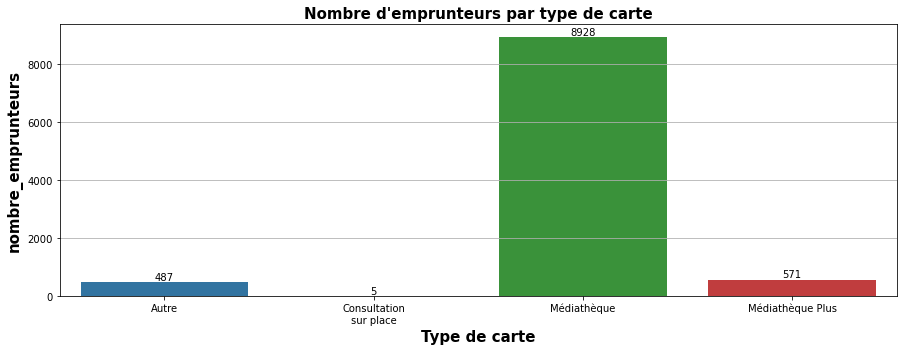

In [49]:
ax = sns.barplot(data=emprunteurs_par_carte,x="Type de carte",y="nombre_emprunteurs")
ax.set_title("Nombre d'emprunteurs par type de carte")


for i in ax.containers:
    ax.bar_label(i,)

In [50]:
#query = """SELECT * FROM statdb.iris_pop"""

#iris = pd.read_sql(query,db_conn)

#total_hab_par_quartier = iris.groupby("irisInsee")["nb_hab"].sum().reset_index()
#total_hab_par_quartier['irisInsee'] = total_hab_par_quartier['irisInsee'].astype(str)

#emprunteurs_rbx = inscrits[inscrits['geo_ville'] == 'ROUBAIX']
#emprunteurs_rbx_par_quartier = emprunteurs_rbx.groupby(['geo_roubaix_iris'])['date_extraction'].count().reset_index()
#emprunteurs_rbx_par_quartier.columns = ['geo_roubaix_iris', 'nb_inscrits']
#total_hab_par_quartier.columns = ['geo_roubaix_iris', 'nb_hab']
#emprunteurs_rbx_par_quartier = emprunteurs_rbx_par_quartier.merge(total_hab_par_quartier, how='left', on='geo_roubaix_iris')#emprunteurs_rbx_par_quartier

#emprunteurs_rbx_par_quartier